In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_excel("Employee.xlsx")
df.head(10)

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City
0,E02387,Emily Davis,Sr. Manger,IT,Research & Development,Female,Black,55,2016-04-08,141604,0.15,United States,Seattle
1,E04105,Theodore Dinh,Technical Architect,IT,Manufacturing,Male,Asian,59,1997-11-29,99975,0.00,China,Chongqing
2,E02572,Luna Sanders,Director,Finance,Speciality Products,Female,Caucasian,50,2006-10-26,163099,0.20,United States,Chicago
3,E02832,Penelope Jordan,Computer Systems Manager,IT,Manufacturing,Female,Caucasian,26,2019-09-27,84913,0.07,United States,Chicago
4,E01639,Austin Vo,Sr. Analyst,Finance,Manufacturing,Male,Asian,55,1995-11-20,95409,0.00,United States,Phoenix
5,E00644,Joshua Gupta,Account Representative,Sales,Corporate,Male,Asian,57,2017-01-24,50994,0.00,China,Chongqing
6,E01550,Ruby Barnes,Manager,IT,Corporate,Female,Caucasian,27,2020-07-01,119746,0.10,United States,Phoenix
7,E04332,Luke Martin,Analyst,Finance,Manufacturing,Male,Black,25,2020-05-16,41336,0.00,United States,Miami
8,E04533,Easton Bailey,Manager,Accounting,Manufacturing,Male,Caucasian,29,2019-01-25,113527,0.06,United States,Austin
9,E03838,Madeline Walker,Sr. Analyst,Finance,Speciality Products,Female,Caucasian,34,2018-06-13,77203,0.00,United States,Chicago


In [4]:
'''
1.Employee data-sini oxuyun
2.numeric columnlar uchun outlier boxplot ile gosterin
3.Departamentleri hem value counts hem de countplot ile gosterin
4.Her departament uchun maashin ortalamasi, yashin minimumu ve bonuslarin maximumun gosterin 
5.Olkeler uzre maashin maksimumu, yashin ortalamasi ve bonuslarin ortalamasin gosterin 
6.Sutunlar uzre korrelasiyaya baxin . Hansi sutunlar bir birinden chox asilidir. Biznes mentiqi varmi?
7.barplot ile sheherler uchun orta maashi plot edin, en yuksek orta maash hansi sheherdedir qeyd edin.


'''


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           1000 non-null   object        
 1   Full Name      1000 non-null   object        
 2   Job Title      1000 non-null   object        
 3   Department     1000 non-null   object        
 4   Business Unit  1000 non-null   object        
 5   Gender         1000 non-null   object        
 6   Ethnicity      1000 non-null   object        
 7   Age            1000 non-null   int64         
 8   Hire Date      1000 non-null   datetime64[ns]
 9   Annual Salary  1000 non-null   int64         
 10  Bonus %        1000 non-null   float64       
 11  Country        1000 non-null   object        
 12  City           1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(9)
memory usage: 101.7+ KB


In [5]:
df.isnull().sum()

EEID             0
Full Name        0
Job Title        0
Department       0
Business Unit    0
Gender           0
Ethnicity        0
Age              0
Hire Date        0
Annual Salary    0
Bonus %          0
Country          0
City             0
dtype: int64

In [6]:
df.describe()

,Age,Hire Date,Annual Salary,Bonus %
count,1000.000000,1000,1000.000000,1000.000000
mean,44.382000,2012-04-07 02:54:14.400000,113217.365000,0.088660
min,25.000000,1992-01-09 00:00:00,40063.000000,0.000000
25%,35.000000,2007-02-14 00:00:00,71430.250000,0.000000
50%,45.000000,2014-02-15 12:00:00,96557.000000,0.000000
75%,54.000000,2018-06-22 00:00:00,150782.250000,0.150000
max,65.000000,2021-12-26 00:00:00,258498.000000,0.400000
std,11.246981,NaN,53545.985644,0.117856


Age
0


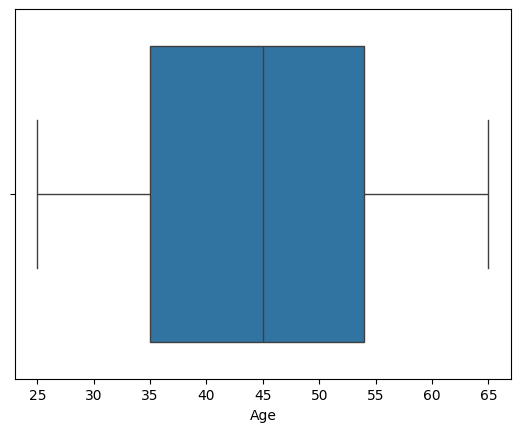

Annual Salary
0


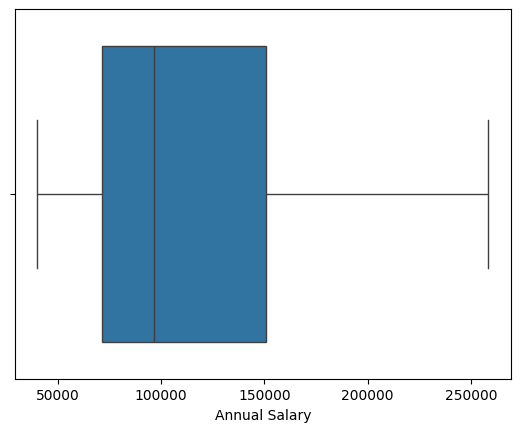

Bonus %
22


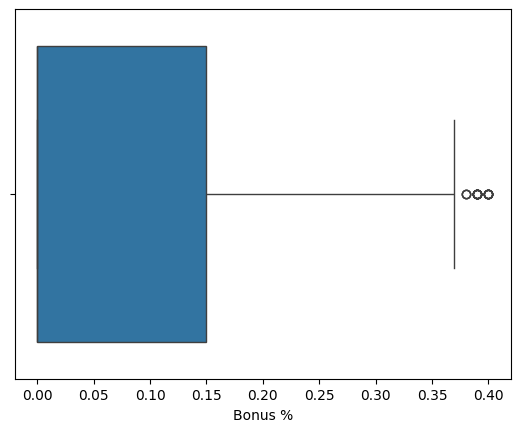

In [14]:
#countt={}
#.numeric columnlar uchun outlier boxplot ile gosterin

for i in df.select_dtypes(include='number').columns:
    q1 = np.quantile(df[i], 0.25)
    q3 = np.quantile(df[i], 0.75)
    iqr = q3 - q1 
    minn = q1 - 1.5* iqr
    maxx = q3 + 1.5 *iqr

    
    countt = ((df[i] < minn) | (df[i] > maxx)).sum()
    print(i)
    print(countt)
    sns.boxplot(data = df , x = i)
    plt.show()
    



#countt


In [35]:
#3.Departamentleri hem value counts hem de countplot ile gosterin
df['Department'].value_counts()

Department
IT                 241
Engineering        158
Sales              140
Human Resources    125
Finance            120
Marketing          120
Accounting          96
Name: count, dtype: int64

<Axes: xlabel='Department', ylabel='count'>

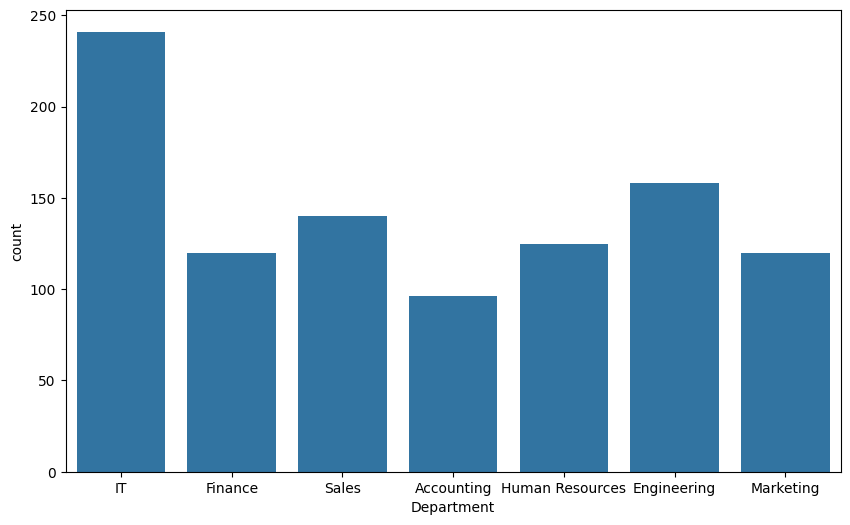

In [34]:

plt.figure(figsize=(10,6))  # Set figure size

sns.countplot(data=df, x='Department')



In [49]:
#4.Her departament uchun maashin ortalamasi, yashin minimumu ve bonuslarin maximumun gosterin 
df.groupby('Department')['Annual Salary'].mean()

Department
Accounting         123146.947917
Engineering        109035.208861
Finance            122802.891667
Human Resources    118058.440000
IT                  97790.452282
Marketing          129663.033333
Sales              111049.857143
Name: Annual Salary, dtype: float64

<Axes: xlabel='Department', ylabel='Annual Salary'>

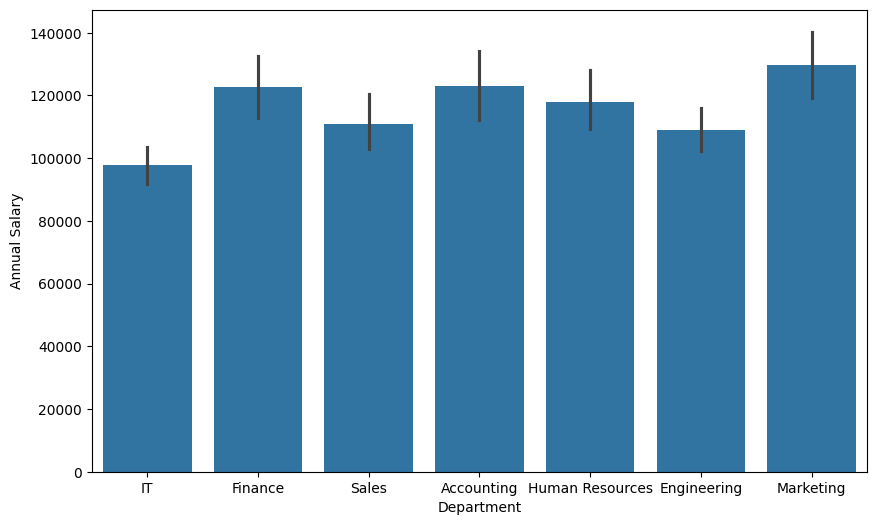

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(data=df, x='Department', y='Annual Salary')

In [63]:
min_age=df.groupby('Department')['Age'].min()
min_age

Department
Accounting         25
Engineering        25
Finance            25
Human Resources    25
IT                 25
Marketing          25
Sales              25
Name: Age, dtype: int64

<Axes: xlabel='Department'>

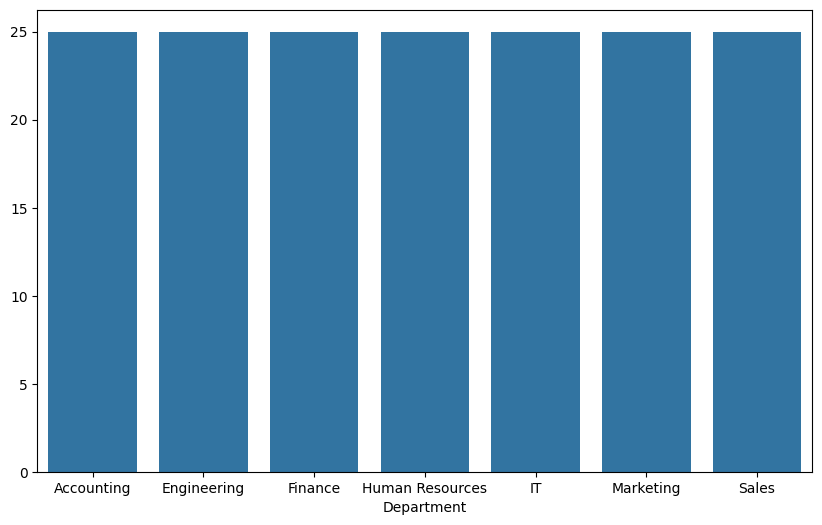

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(x=min_age.index, y=min_age.values)

<Axes: xlabel='Department'>

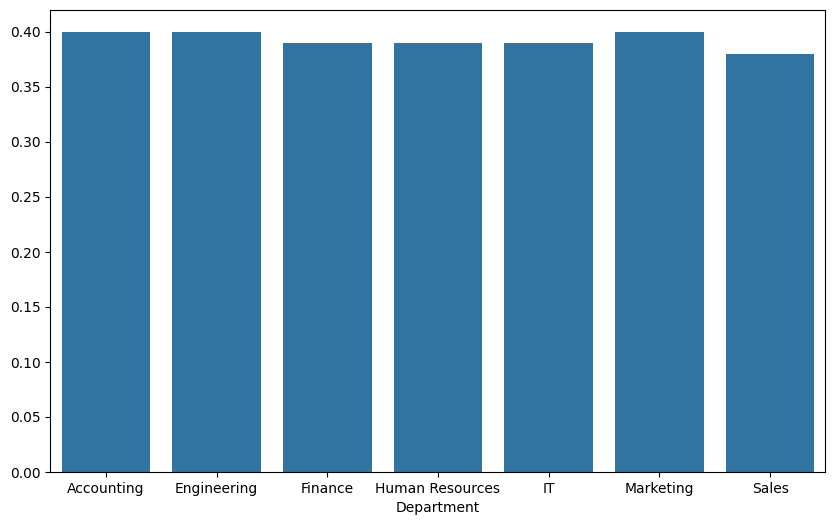

In [69]:
max_bonus=df.groupby('Department')['Bonus %'].max()
plt.figure(figsize=(10,6))

sns.barplot(x=max_bonus.index, y=max_bonus.values)

In [71]:
#5.Olkeler uzre maashin maksimumu, yashin ortalamasi ve bonuslarin ortalamasin gosterin 
max_salary=df.groupby('Country')['Annual Salary'].max()
mean_age=df.groupby('Country')['Age'].mean()
mean_bonus=df.groupby('Country')['Bonus %'].mean()

/var/folders/qy/0qtnbdzn1pb0vd98b2s698n40000gn/T/ipykernel_2469/2004537013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=max_salary.index, y=max_salary.values, palette='viridis' , ax=axes[0])
/var/folders/qy/0qtnbdzn1pb0vd98b2s698n40000gn/T/ipykernel_2469/2004537013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_age.index, y=mean_age.values, palette='viridis', ax=axes[1])
/var/folders/qy/0qtnbdzn1pb0vd98b2s698n40000gn/T/ipykernel_2469/2004537013.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_bonus.index, y=me

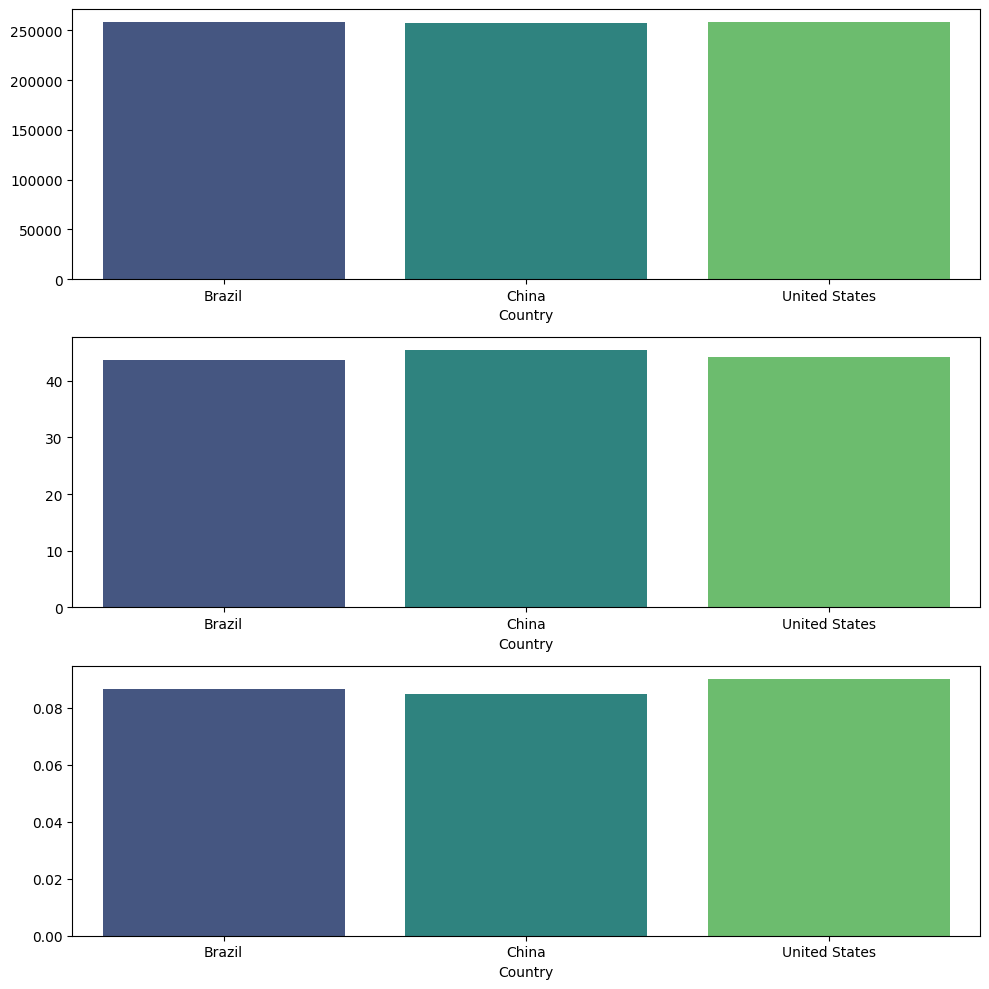

In [95]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10)) 


sns.barplot(x=max_salary.index, y=max_salary.values, palette='viridis' , ax=axes[0])



sns.barplot(x=mean_age.index, y=mean_age.values, palette='viridis', ax=axes[1])



sns.barplot(x=mean_bonus.index, y=mean_bonus.values, palette='viridis', ax=axes[2])

plt.tight_layout() 
plt.show()

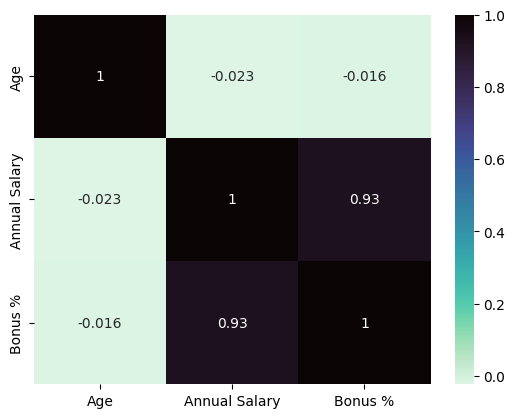

In [94]:
#6.Sutunlar uzre korrelasiyaya baxin . Hansi sutunlar bir birinden chox asilidir. Biznes mentiqi varmi?


corr = df[['Age','Annual Salary','Bonus %']].corr()
sns.heatmap(corr, annot=True, cmap="mako_r")
plt.show()
## annaul salary bonusla duz aasilidir


City
Austin            116000.767677
Beijing           108979.890909
Chengdu           110387.369565
Chicago           112293.413043
Chongqing         115434.953846
Columbus          116108.380531
Manaus            115079.500000
Miami             112765.250000
Phoenix           107438.834862
Rio de Janerio    108275.931818
Sao Paulo         113503.245283
Seattle           114532.415254
Shanghai          119972.019231
Name: Annual Salary, dtype: float64

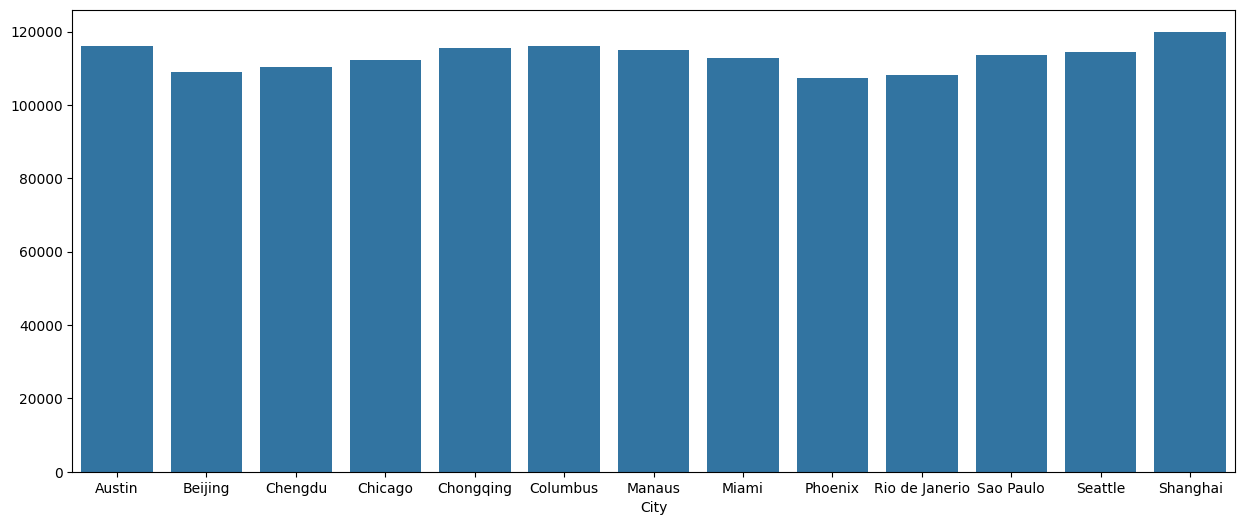

In [101]:
#7.barplot ile sheherler uchun orta maashi plot edin, en yuksek orta maash hansi sheherdedir qeyd edin.
mean_sal_city=df.groupby('City')['Annual Salary'].mean()
plt.figure(figsize=(15,6))
sns.barplot(x=mean_sal_city.index, y=mean_sal_city.values)
df.groupby('City')['Annual Salary'].mean()
#Shanghai dadir